# Binary Classifier: Fake Ground-Truth Data & Response Analysis

This notebook studies **how different "quality levels" of a binary classifier's
outputs look** on synthetic data. We never learn anything — we only

1. fabricate a **ground-truth target** `y` (binary, 1000 samples) under three
   class-balance regimes,
2. fabricate **responses** `y_hat` in `[0, 1]` of six different kinds of
   (de)quality, and
3. evaluate every `(dataset, response)` pair with
   - **ROC AUC** (threshold-free ranking quality),
   - **Precision–Recall curve and its area (average precision)**,
   - **thresholded metrics at 0.5**: accuracy, precision, recall and **F1**.

> **Why synthetic data?** The point is to *see* the geometry of ROC/PR curves
> and the behaviour of accuracy vs. F1 under class imbalance, in a fully
> controlled setting where we know the true answer by construction.

## The three datasets (1000 samples each)

| Dataset          | Positive rate `P(y=1)` | Intuition                                          |
|------------------|:----------------------:|----------------------------------------------------|
| `balanced_50_50` | 50%                    | both classes equally common                        |
| `imb_30_70`      | 30%                    | mild imbalance (a "30% / 70%" split)                |
| `imb_10_90`      | 10%                    | strong imbalance — rare event (fraud, disease, …)   |

## The six response types (`y_hat` in `[0, 1]`)

| Response     | Construction                       | Simulates                              |
|--------------|------------------------------------|----------------------------------------|
| `perfect`    | `y_hat = y`                        | an oracle that is exactly right        |
| `inverted`   | `y_hat = 1 - y`                    | a model that is *systematically wrong* |
| `random`     | `y_hat ~ Uniform(0, 1)`            | pure guessing, no signal               |
| `majority`   | `y_hat = 0` (constant, every sample)| a model that *always* predicts the majority class |
| `noise~0.8`  | `(1-ρ)·y + ρ·U`, AUC calibrated ≈ 0.8 | a *good* model with imperfect confidence |
| `noise~0.6`  | same, AUC calibrated ≈ 0.6         | a *mediocre* model                     |

The noise families mix the true label with uniform noise; the mixing weight
`ρ` is **calibrated per dataset** by a small grid search so that the *achieved*
ROC AUC lands as close as possible to 0.8 / 0.6 (sampling noise makes the
achieved value only approximate — the notebook prints what it actually got).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score, auc,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
)
import pandas as pd

SEED = 42          # global seed for full reproducibility
N = 1000           # number of samples per dataset (as requested)
THRESHOLD = 0.5    # decision threshold for accuracy / precision / recall / F1

# Consistent colors/style per response type, used by every plot
STYLES = {
    'perfect':  dict(color='tab:green',  marker='o', ls='-'),
    'inverted': dict(color='tab:red',    marker='x', ls='-'),
    'random':   dict(color='gray',       marker='.', ls='--'),
    'majority': dict(color='tab:purple', marker='s', ls='-.'),
    'noise~0.8':dict(color='tab:blue',   marker='',  ls='-'),
    'noise~0.6':dict(color='tab:orange', marker='',  ls='-'),
}

print('numpy     :', np.__version__)
print('sklearn   :', __import__('sklearn').__version__)
print('matplotlib:', plt.matplotlib.__version__)
print('pandas    :', pd.__version__)

numpy     : 2.5.3
sklearn   : 1.9.1
matplotlib: 3.11.2
pandas    : 3.0.6


## 1. Fabricating the ground truth `y`

Each dataset is an i.i.d. sequence of Bernoulli draws with a positive rate
`p`. The labels are not correlated with anything — there is no feature `x`
at all. That is exactly the point: we analyse the **target/response joint
distribution**, not a learned model.

In [2]:
DATASETS = {}    # name -> y array (int 0/1, length N)
POS_RATES = {
    'balanced_50_50': 0.50,
    'imb_30_70'       : 0.30,
    'imb_10_90'       : 0.10,
}

# One dedicated RNG per dataset so every draw is reproducible and independent
for i, (name, p) in enumerate(POS_RATES.items()):
    rng = np.random.default_rng(SEED + 100 + i)
    y = (rng.random(N) < p).astype(int)      # Bernoulli(p): 1 with prob p
    DATASETS[name] = y

# Confirm the imbalance levels by printing class counts per dataset
overview = pd.DataFrame([
    {'dataset': name,
      'n_samples': len(y),
      'n_pos (y=1)': int(y.sum()),
      'n_neg (y=0)': int((y == 0).sum()),
      'pos_rate'   : y.mean()}
    for name, y in DATASETS.items()
]).T
overview

,0,1,2
dataset,balanced_50_50,imb_30_70,imb_10_90
n_samples,1000,1000,1000
n_pos (y=1),468,295,110
n_neg (y=0),532,705,890
pos_rate,0.468,0.295,0.11


## 2. Fabricating the responses `y_hat`

All six responses live in `[0, 1]`, exactly what a `sigmoid`/`softmax` binary
classifier emits.

- **`perfect`** — `y_hat = y`. With *deterministic* probabilities the ROC curve
  hugs the top-left corner and AUC = **1.0** exactly.
- **`inverted`** — `y_hat = 1 - y`. The ranking is *maximally*
  anti-correlated, so AUC = **0.0** exactly (below 0.5! Flipping this "model"
  would make it perfect — a classic pathology AUC exposes).
- **`random`** — `y_hat ~ U(0,1)`, independent of `y`. Its ranking carries no
  information, so AUC hovers around **0.5**, *regardless of class balance*:
  AUC is an imbalance-invariant ranking statistic.
- **`majority`** — `y_hat = 0`, the *same constant* for every sample. This is
  the "lazy" model that always answers with the majority class (class 0, the
  majority in all three datasets). All scores tie, so AUC = **0.5** exactly
  and average precision = **the positive rate** (the random PR baseline). At
  threshold 0.5 it produces *zero* positives, hence **F1 = 0.00** everywhere,
  while accuracy lands exactly at the *negative* rate (0.5 / 0.7 / 0.9) —
  the classic "accuracy looks fine, the model is useless" case.
- **`noise~0.8` / `noise~0.6`** — *probabilistic* responses:

  ```
  y_hat = (1 - ρ) · y + ρ · U(0,1),     U ~ Uniform(0, 1)
  ```

  With `ρ = 0` we recover the perfect model; as `ρ → 1` the label information
  washes out and AUC → 0.5. Geometrically, positives get scores from
  `U(1-ρ, 1)` and negatives from `U(0, ρ)`, so the two score distributions
  overlap on the middle interval — and **that overlap is the AUC deficit**.
  We grid-search `ρ` per dataset and keep the value whose *achieved* AUC is
  closest to the target (0.8 or 0.6); the achieved value is printed.

In [3]:
def make_responses(y, seed, targets=((0.8, 'noise~0.8'), (0.6, 'noise~0.6'))):
    """Generate the 6 canonical responses for a ground-truth array y.

    Returns an ordered dict {response_name: y_hat array}.
    The noise responses are calibrated by a grid over the mixing weight rho,
    keeping the rho whose achieved ROC AUC is closest to the target.
    """
    rng = np.random.default_rng(seed)
    out = {}

    # 1) perfectly correct: probabilities equal the labels
    out['perfect'] = y.astype(float)

    # 2) perfectly wrong: anti-correlated probabilities
    out['inverted'] = 1.0 - y.astype(float)

    # 3) pure noise: independent of y
    out['random'] = rng.random(len(y))

    # 4) constant majority-class score: below any threshold, class 0 always
    out['majority'] = np.zeros(len(y))

    # 5/6) label + uniform noise, rho calibrated to a target AUC
    for target, name in targets:
        grid = np.linspace(0.501, 0.999, 160)     # rho values to try
        best = None                                # (|deviation|, rho, achieved AUC)
        for rho in grid:
            ph = (1.0 - rho) * y + rho * rng.random(len(y))
            a = roc_auc_score(y, ph)
            if best is None or abs(a - target) < best[0]:
                best = (abs(a - target), rho, a)
        _, rho, achieved = best
        out[name] = (1.0 - rho) * y + rho * rng.random(len(y))  # final draw
        print(f"{name:<10s} rho={rho:.4f}  ->  achieved AUC = {achieved:.4f} (target {target})")
    return out

RESPONSES = {
    name: make_responses(y, seed=SEED + 200 + i)
    for i, (name, y) in enumerate(DATASETS.items())
}

noise~0.8  rho=0.7359  ->  achieved AUC = 0.8023 (target 0.8)


noise~0.6  rho=0.8894  ->  achieved AUC = 0.5981 (target 0.6)


noise~0.8  rho=0.7453  ->  achieved AUC = 0.8010 (target 0.8)


noise~0.6  rho=0.8988  ->  achieved AUC = 0.5998 (target 0.6)


noise~0.8  rho=0.7328  ->  achieved AUC = 0.7982 (target 0.8)


noise~0.6  rho=0.9426  ->  achieved AUC = 0.5992 (target 0.6)


## 3. Metrics: what each number means

 Every response `y_hat ∈ [0,1]` is a *probabilistic score*. We evaluate it two
ways:

**A. Threshold-free (ranking quality)**

- **ROC AUC** — `P(score(y=1) > score(y=0))`: the probability that a random
  positive is ranked above a random negative. Range `[0, 1]`; `0.5` = random,
  `1.0` = perfect, `< 0.5` = worse than random (the `inverted` case!).
- **PR curve / average precision** — area under the precision–recall curve.
  **Crucially different from ROC under imbalance**: the baseline for a
  *random* model is the **positive rate** (0.5 / 0.3 / 0.1 here), not 0.5,
  because precision is dominated by the abundance of negatives.

**B. Thresholded at `y_hat >= 0.5`** (i.e. `pred = 1[y_hat ≥ 0.5]`)

- **Accuracy** = `(TP + TN) / N`. Imbalance-sensitive: always predicting the
  majority class already scores 70% or 90%.
- **Precision** = `TP / (TP + FP)` — of the *alerted* samples, how many were
  truly positive.
- **Recall** = `TP / (TP + FN)` — of the *true* positives, how many were caught.
- **F1** = harmonic mean of precision and recall.

The table below covers all **3 datasets × 6 responses = 18 combinations**.

In [4]:
STRATEGY_ORDER = ['perfect', 'inverted', 'random', 'majority', 'noise~0.8', 'noise~0.6']
DS_ORDER = list(DATASETS.keys())

rows = {}
for ds_name, y in DATASETS.items():
    for strat in STRATEGY_ORDER:
        ph = RESPONSES[ds_name][strat]
        preds = (ph >= THRESHOLD).astype(int)          # harden scores at 0.5
        rows[(ds_name, strat)] = dict(
            accuracy  = accuracy_score(y, preds),
            precision = precision_score(y, preds, zero_division=0),
            recall    = recall_score(y, preds),
            F1        = f1_score(y, preds),
            roc_auc   = roc_auc_score(y, ph),          # threshold-free
            pr_auc    = average_precision_score(y, ph) # area under PR curve
        )

results = pd.DataFrame(rows).T
results = results.reindex([(d, s) for d in DS_ORDER for s in STRATEGY_ORDER])
results.index.names = ['dataset', 'response']

table = results[['accuracy', 'precision', 'recall', 'F1', 'roc_auc', 'pr_auc']].round(4)

# ---------------------------------------------------------------------------
# Helper used by the ROC & PR figure cells below: given the y-value of every
# curve at x = 0.5, returns staggered label positions so the *six* per-curve
# area labels never overlap — each label sits just above its own curve.
def _label_positions(curve_val, spacing=0.055):
    order = list(curve_val)
    y0 = [min(curve_val[k] + 0.05, 1.00) for k in order]
    idx = sorted(range(len(order)), key=lambda i: y0[i])
    for i in range(1, len(idx)):                       # push apart, bottom-up
        if y0[idx[i]] - y0[idx[i-1]] < spacing:
            y0[idx[i]] = y0[idx[i-1]] + spacing
    for i in range(len(idx)-1, 0, -1):                 # keep everything in frame
        if i+1 < len(idx) and y0[idx[i]] > y0[idx[i+1]] - spacing:
            y0[idx[i]] = y0[idx[i+1]] - spacing
    return [max(0.03, min(v, 1.00)) for v in y0]

table

accuracy  precision  recall      F1  roc_auc  pr_auc
dataset        response                                                       
balanced_50_50 perfect       1.000     1.0000  1.0000  1.0000   1.0000  1.0000
               inverted      0.000     0.0000  0.0000  0.0000   0.0000  0.4680
               random        0.487     0.4545  0.4808  0.4673   0.4744  0.4445
               majority      0.532     0.0000  0.0000  0.0000   0.5000  0.4680
               noise~0.8     0.659     0.6248  0.6795  0.6510   0.7925  0.8038
               noise~0.6     0.561     0.5291  0.5641  0.5460   0.6138  0.6155
imb_30_70      perfect       1.000     1.0000  1.0000  1.0000   1.0000  1.0000
               inverted      0.000     0.0000  0.0000  0.0000   0.0000  0.2950
               random        0.489     0.2831  0.4780  0.3556   0.4788  0.2849
               majority      0.705     0.0000  0.0000  0.0000   0.5000  0.2950
               noise~0.8     0.681     0.4712  0.6644  0.5513   0.7885  0.6834
               noise~0.6     0.571     0.3550  0.5559  0.4333   0.6122  0.4631
imb_10_90      perfect       1.000     1.0000  1.0000  1.0000   1.0000  1.0000
               inverted      0.000     0.0000  0.0000  0.0000   0.0000  0.1100
               random        0.500     0.1161  0.5364  0.1909   0.5415  0.1297
               majority      0.890     0.0000  0.0000  0.0000   0.5000  0.1100
               noise~0.8     0.688     0.2147  0.6909  0.3276   0.8014  0.5485
               noise~0.6     0.531     0.1140  0.4818  0.1843   0.5208  0.1757

## 4. ROC curves (one panel per dataset)

For every response we sweep the decision threshold over all observed scores and
plot `FPR = FP/(FP+TN)` (x-axis) vs `TPR = TP/(TP+FN)` (y-axis).

**Key observations:**

1. `perfect` sticks to the top-left corner (AUC = 1.0) and `inverted` to the
   bottom-right (AUC = 0.0) — on *every* panel, as designed.
2. **ROC curves barely reflect class imbalance** — the same six responses
   sit in the same place on all three panels (up to sampling noise). That is
   AUC's celebrated strength *and* weakness: it hides how many false alarms
   you will actually fire in an imbalanced population. For that, read the PR
   curves next.
3. Both noise responses sit comfortably above the dashed 0.5-random diagonal,
   while `random` hugs it with only sampling wiggle.

/tmp/ipykernel_133089/3422700188.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


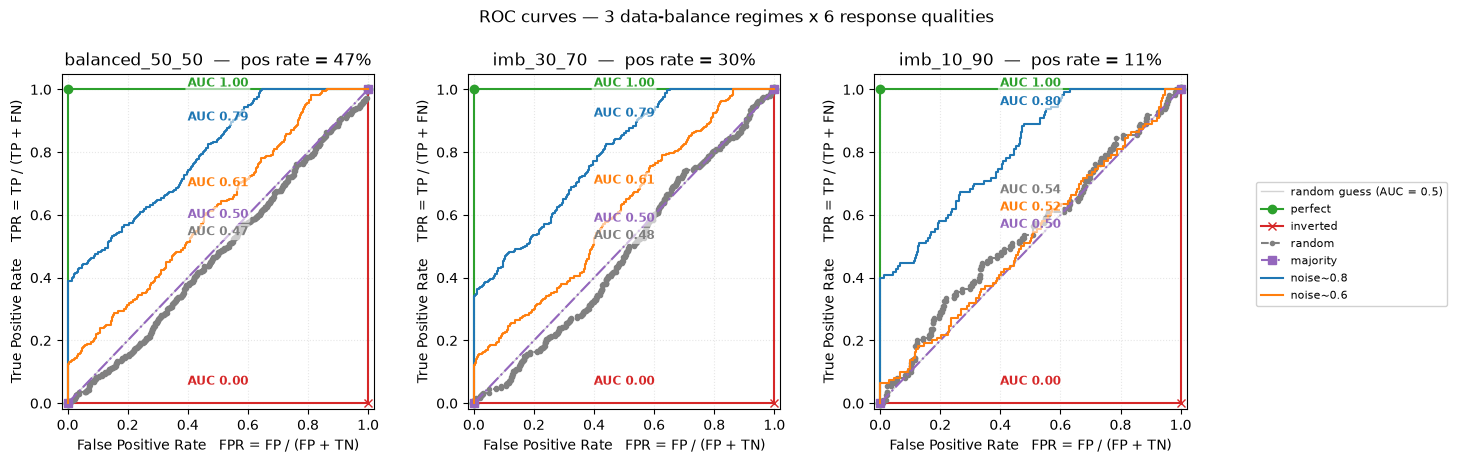

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, ds_name in zip(axes, DS_ORDER):
    y = DATASETS[ds_name]
    pos_rate = y.mean()

    # random-guess baseline: the ROC diagonal (identical for every imbalance)
    ax.plot([0, 1], [0, 1], color='lightgray', lw=1)

    # per-response: achieved AUC + curve height at x=0.5 (for the labels)
    auc_map, curve_at = {}, {}
    for strat in STRATEGY_ORDER:
        ph = RESPONSES[ds_name][strat]
        fpr, tpr, _ = roc_curve(y, ph)
        ax.plot(fpr, tpr, **STYLES[strat])
        auc_map[strat]  = roc_auc_score(y, ph)
        curve_at[strat] = float(np.interp(0.5, fpr, tpr))

    # area-under-curve labels, just above each curve at x = 0.5,
    # staggered vertically where curves are close (e.g. random vs majority)
    for strat, ly in zip(STRATEGY_ORDER, _label_positions(curve_at)):
        ax.text(0.5, ly, f"AUC {auc_map[strat]:.2f}", ha='center', va='bottom',
                color=STYLES[strat]['color'], fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none',
                          alpha=0.6))

    ax.set_title(f"{ds_name}  —  pos rate = {pos_rate:.0%}")
    ax.set_xlabel('False Positive Rate   FPR = FP / (FP + TN)')
    ax.set_ylabel('True Positive Rate    TPR = TP / (TP + FN)')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
    ax.grid(alpha=0.3, ls=':')

# legend OUTSIDE the panels (right sidebar) so it never covers the curves;
# numeric AUC values are in the results table above, so the legend only names
from matplotlib.lines import Line2D
lax = fig.add_axes([0.835, 0.14, 0.15, 0.66])
handles = [Line2D([0], [0], color='lightgray', lw=1)] +           [Line2D([0], [0], **STYLES[s]) for s in STRATEGY_ORDER]
labels  = ['random guess (AUC = 0.5)'] + STRATEGY_ORDER
lax.legend(handles, labels, loc='center', fontsize=8, framealpha=0.9,
           handletextpad=0.7, columnspacing=0.8, borderaxespad=0.3)
lax.axis('off')

fig.subplots_adjust(left=0.05, right=0.80, top=0.84, wspace=0.30)
fig.suptitle('ROC curves — 3 data-balance regimes x 6 response qualities', fontsize=12)
fig.show()

## 5. Precision–Recall curves (one panel per dataset)

Each curve point is a threshold choice, plotting
**precision = TP/(TP+FP)** (y-axis) vs **recall = TP/(TP+FN)** (x-axis).

**Why PR is the more informative plot under imbalance:**

- A *random* classifier's expected precision is the **positive rate** — that's
  the dashed horizontal line in each panel (0.5 / 0.3 / 0.1). On the
  `imb_10_90` panel the gap between random and any useful model is *huge* and
  obvious — while the ROC panels made all three datasets look identical.
- `inverted` collapses to precision = 0 everywhere: every single alerted
  sample is a false alarm.
- `noise~0.8` keeps much more PR-AUC than `noise~0.6`: the same ranking loss
  that costs little on ROC costs visibly more in average precision.

/tmp/ipykernel_133089/633712346.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


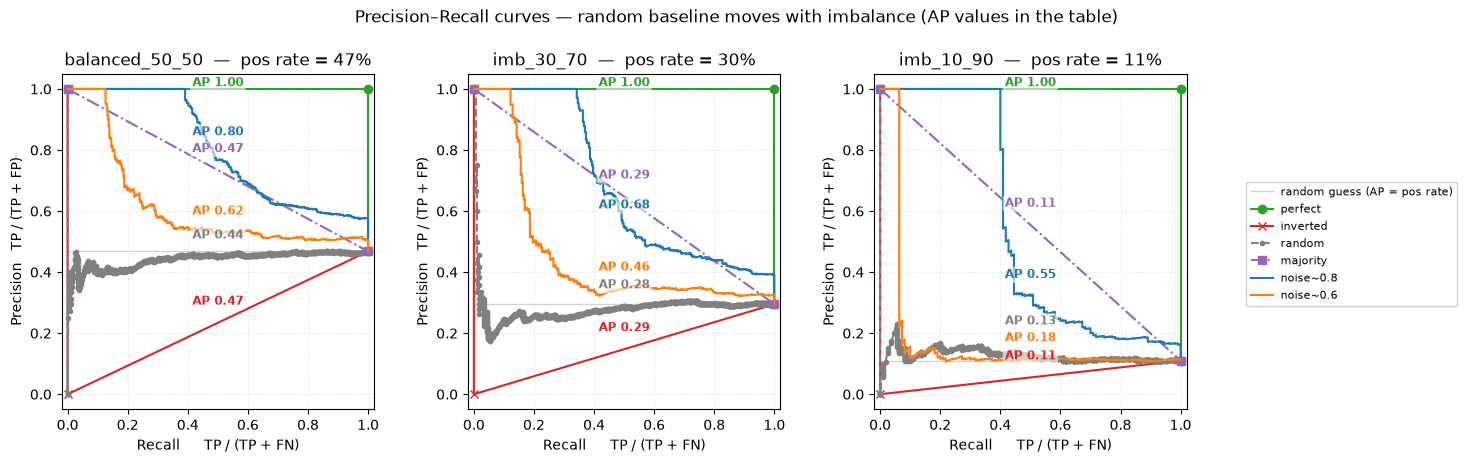

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, ds_name in zip(axes, DS_ORDER):
    y = DATASETS[ds_name]
    pos_rate = y.mean()

    # random baseline for PR = the positive class frequency
    ax.hlines(pos_rate, 0, 1, color='lightgray', lw=1)

    # per-response: achieved AP + precision at recall=0.5 (for the labels)
    ap_map, curve_at = {}, {}
    for strat in STRATEGY_ORDER:
        ph = RESPONSES[ds_name][strat]
        prec, rec, _ = precision_recall_curve(y, ph)
        # sklearn returns recall decreasing -> flip for the conventional direction
        rec, prec = rec[::-1], prec[::-1]
        ax.plot(rec, prec, **STYLES[strat])
        ap_map[strat]  = average_precision_score(y, ph)
        curve_at[strat] = float(np.interp(0.5, rec, prec))

    # area-under-curve (average precision) labels, just above each curve
    for strat, ly in zip(STRATEGY_ORDER, _label_positions(curve_at)):
        ax.text(0.5, ly, f"AP {ap_map[strat]:.2f}", ha='center', va='bottom',
                color=STYLES[strat]['color'], fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none',
                          alpha=0.6))

    ax.set_title(f"{ds_name}  —  pos rate = {pos_rate:.0%}")
    ax.set_xlabel('Recall      TP / (TP + FN)')
    ax.set_ylabel('Precision   TP / (TP + FP)')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3, ls=':')

# legend OUTSIDE the panels (right sidebar); AP values are in the results table
from matplotlib.lines import Line2D
lax = fig.add_axes([0.835, 0.14, 0.15, 0.66])
handles = [Line2D([0], [0], color='lightgray', lw=1)] +           [Line2D([0], [0], **STYLES[s]) for s in STRATEGY_ORDER]
labels  = ['random guess (AP = pos rate)'] + STRATEGY_ORDER
lax.legend(handles, labels, loc='center', fontsize=8, framealpha=0.9,
           handletextpad=0.7, columnspacing=0.8, borderaxespad=0.3)
lax.axis('off')

fig.subplots_adjust(left=0.05, right=0.80, top=0.84, wspace=0.30)
fig.suptitle('Precision–Recall curves — random baseline moves with imbalance (AP values in the table)',
             fontsize=12)
fig.show()

## 6. Thresholded performance: Accuracy & F1 per (dataset, response)

Hardening every probabilistic response at **0.5** yields binary predictions,
from which we compute accuracy and F1. Bars are grouped per response, one bar
per dataset.

**What to notice:**

- `perfect` scores **1.00 everywhere** — no surprise.
- `inverted` gets accuracy **0.00** on every panel: because the labels are
  exact 0/1, `1 - y` flips *every single sample* — and AUC = 0.00 confirms it
  is maximally wrong (flipping its output would make it perfect).
  **F1 is 0** as well, which shows why F1 / precision / recall are the right
  lenses for the positive class.
- `random`'s accuracy lands near ~50% on every panel (thresholding a uniform
  score is a coin flip), while its **F1 varies strongly with imbalance** —
  the same coin flip is judged very differently when 90% of samples are 0.
- `majority` is the *cautionary* case: accuracy is exactly the **negative
  rate** (0.5 / 0.7 / 0.9) — looking respectable on `imb_10_90`! — yet F1 is
  **0.00** on all three panels, since it never once predicts class 1.
  Accuracy alone would hide a useless model; F1 does not.
- The two noise models separate cleanly: more signal → higher F1, and the
  penalty for imperfect signal grows with imbalance (precision gets hard).

/tmp/ipykernel_133089/852482506.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


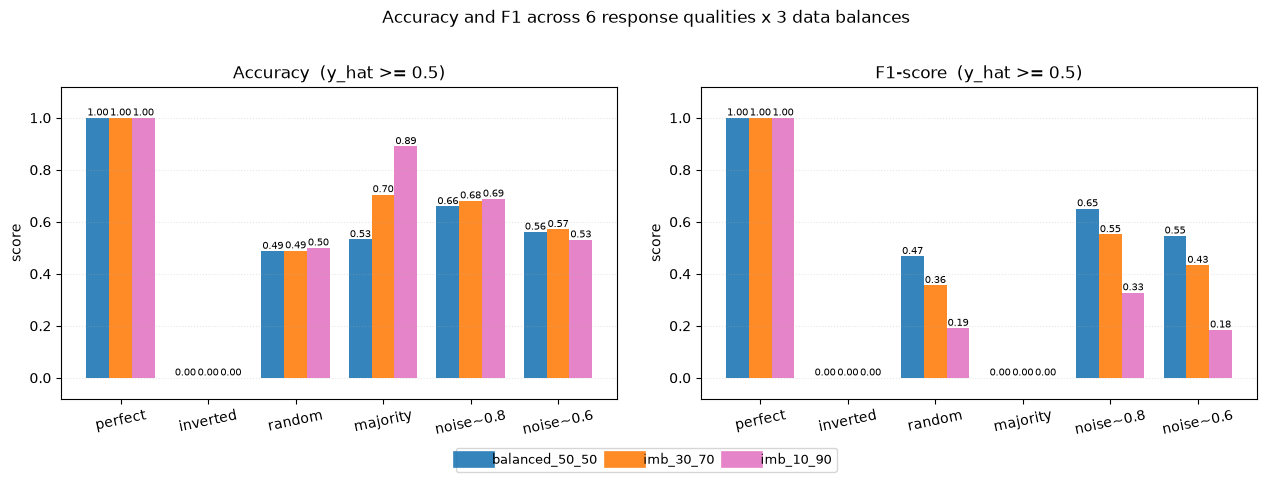

In [7]:
# Pivot to wide tables: rows = responses, columns = datasets
acc = results['accuracy'].unstack('dataset')[DS_ORDER].reindex(STRATEGY_ORDER)
f1  = results['F1']      .unstack('dataset')[DS_ORDER].reindex(STRATEGY_ORDER)

x = np.arange(len(STRATEGY_ORDER))
w = 0.26   # width of one bar inside a cluster

ds_colors = {'balanced_50_50': 'tab:blue',
              'imb_30_70'     : 'tab:orange',
              'imb_10_90'     : 'tab:pink'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, tab, title in [(axes[0], acc, 'Accuracy  (y_hat >= 0.5)'),
                       (axes[1], f1 , 'F1-score  (y_hat >= 0.5)')]:
    for j, ds_name in enumerate(DS_ORDER):
        vals = list(tab[ds_name])
        xs = x + (j - 1) * w
        ax.bar(xs, vals, width=w, label=ds_name, color=ds_colors[ds_name], alpha=0.9)
        for xi, v in zip(xs, vals):            # annotate each bar with its value
            ax.annotate(f"{v:.2f}", (xi, v), ha='center', va='bottom', fontsize=7)
    ax.set_title(title)
    ax.set_xticks(x); ax.set_xticklabels(STRATEGY_ORDER, rotation=12)
    ax.set_ylim(-0.08, 1.12); ax.set_ylabel('score')
    ax.grid(axis='y', alpha=0.3, ls=':')

# legend OUTSIDE the bar panels (horizontal strip below the bars)
from matplotlib.lines import Line2D
lax = fig.add_axes([0.10, 0.015, 0.80, 0.055])
handles = [Line2D([0], [0], lw=12, color=ds_colors[d], alpha=0.9) for d in DS_ORDER]
lax.legend(handles, DS_ORDER, loc='center', ncol=6, frameon=True,
           columnspacing=1.2, fontsize=9, handletextpad=0.5)
lax.axis('off')

fig.subplots_adjust(left=0.05, right=0.97, top=0.82, bottom=0.17, wspace=0.15)
fig.suptitle('Accuracy and F1 across 6 response qualities x 3 data balances', fontsize=12)
fig.show()

## 7. Take-aways

| Response  | ROC AUC | PR-AUC vs random | Accuracy on `imb_10_90` | F1 trend |
|-----------|:-------:|:----------------:|:-----------------------:|:--------:|
| `perfect`     |  1.0   |     above        |           1.00          |    1.00  |
| `inverted`    |  0.0   |     0            |         0.00            |     0.00 |
| `random`      | ~0.5   |     = baseline   |         ~0.50           | varies with imbalance |
| `majority`    |  0.5   |  = baseline (exact) |         0.90           |         0.00          |
| `noise~0.8`   | ~0.8   |  clearly above   |   better than random    |   solid  |
| `noise~0.6`   | ~0.6   |     above        |   slightly better       | thinner  |

1. **AUC is imbalance-blind** — all three datasets yield nearly identical ROC
   panels. Use ROC/AUC to compare *rankings*; use PR/AP to understand the
   *operational cost* of a model in an imbalanced world.
2. **AUC < 0.5 is a red flag, not noise** — the model is confidently wrong and
   can be instantly improved by flipping its output (the `inverted` case).
3. **Accuracy is a poor referee for the positive class** under imbalance:
   the `majority` response "scores" 0.5 / 0.7 / 0.9 accuracy (just by always
   predicting 0) while its F1 is 0.00 everywhere; F1 anchors the discussion
   to what we actually care about — the positives.
4. **The 0.5 threshold is arbitrary.** Responses with similar AUC but
   different score distributions (e.g. `perfect` vs `noise~0.8`) give very
   different F1 at a fixed threshold — *calibration* matters, not just ranking.
5. When reporting a binary classifier on imbalanced data, report at least
   **AP (PR-AUC), ROC-AUC and F1 (with the threshold stated)** — a single
   number always hides part of the story.

*Everything is reproducible: global seed = 42; per-dataset and per-response
RNGs are deterministic offsets from it.*